# **<center style="color: green;">Desafío - Preprocesamiento de datos</center>**

#### **Nombre:** Cristian Tobar Morales ###
#### **Curso:** Machine Learning ###

In [1]:
# ==========================================
# 1. Importación de Librerías
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn: Herramientas de Feature Selection y Modelado Base
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

# Configuración visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# ==========================================
# 2. Carga del Dataset y Exploración Inicial
# ==========================================
# Reemplaza 'anime_dataset.csv' por el nombre exacto de tu archivo
nombre_archivo = '/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/7_Aplicando lo aprendido/imdb_anime.xlsx' 

try:
    df = pd.read_excel(nombre_archivo)
    print(f"✅ Dataset cargado correctamente desde {nombre_archivo}.\n")
    
    display(df.head())
    
    print("\n--- Información general del dataset ---")
    df.info()
    
except FileNotFoundError:
    print(f"❌ Error: No se encontró el archivo '{nombre_archivo}'.")

✅ Dataset cargado correctamente desde /mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/7_Aplicando lo aprendido/imdb_anime.xlsx.



,Title,Genre,User Rating,Number of Votes,Runtime,Year,Summary,Stars,Certificate,Metascore,Gross,Episode,Episode Title
0,One Piece,"Animation, Action, Adventure",8.9,187689,24 min,(1999– ),Follows the adventures of Monkey D. Luffy and ...,"Mayumi Tanaka,Laurent Vernin,Akemi Okamura,Ton...",TV-14,NaN,187689,0,NaN
1,Teenage Mutant Ninja Turtles: Mutant Mayhem,"Animation, Action, Adventure",7.4,28895,99 min,-2023,The film follows the Turtle brothers as they w...,NaN,PG,74,28895,0,NaN
2,The Super Mario Bros. Movie,"Animation, Adventure, Comedy",7.1,189108,92 min,-2023,A plumber named Mario travels through an under...,NaN,PG,46,189108,0,NaN
3,Attack on Titan,"Animation, Action, Adventure",9.1,434457,24 min,(2013–2023),After his hometown is destroyed and his mother...,"Josh Grelle,Bryce Papenbrook,Yûki Kaji,Yui Ish...",TV-MA,NaN,434457,0,NaN
4,Jujutsu Kaisen,"Animation, Action, Adventure",8.5,82909,24 min,(2020– ),A boy swallows a cursed talisman - the finger ...,"Junya Enoki,Yûichi Nakamura,Adam McArthur,Yuma...",TV-MA,NaN,82909,0,NaN



--- Información general del dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 45717 entries, 0 to 45716
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Title            45717 non-null  object
 1   Genre            45717 non-null  str   
 2   User Rating      25009 non-null  object
 3   Number of Votes  25009 non-null  object
 4   Runtime          32549 non-null  str   
 5   Year             45591 non-null  object
 6   Summary          23547 non-null  str   
 7   Stars            13676 non-null  str   
 8   Certificate      28694 non-null  object
 9   Metascore        341 non-null    object
 10  Gross            25009 non-null  object
 11  Episode          45717 non-null  object
 12  Episode Title    34910 non-null  object
dtypes: object(9), str(4)
memory usage: 4.5+ MB


In [4]:
    print(f"\nTotal de filas duplicadas: {df.duplicated().sum()}")
    print("\nTotal de valores nulos por columna:")
    print(df.isnull().sum())


Total de filas duplicadas: 874

Total de valores nulos por columna:
Title                  0
Genre                  0
User Rating        20708
Number of Votes    20708
Runtime            13168
Year                 126
Summary            22170
Stars              32041
Certificate        17023
Metascore          45376
Gross              20708
Episode                0
Episode Title      10807
dtype: int64


In [6]:
# ==========================================
# 3. Limpieza y Preprocesamiento (Fase 1) - CORREGIDO
# ==========================================
import re

# 1. Eliminar duplicados absolutos
df_clean = df.drop_duplicates().copy()

# 2. Eliminar ruido en la variable objetivo y quitar nulos
# Convertimos a número forzando que cualquier texto basura se vuelva NaN, luego eliminamos esos NaN
df_clean['User Rating'] = pd.to_numeric(df_clean['User Rating'], errors='coerce')
df_clean = df_clean.dropna(subset=['User Rating'])

# 3. Eliminar columnas con exceso de nulos o de texto libre no estructurado
cols_to_drop = ['Title', 'Summary', 'Stars', 'Certificate', 'Metascore', 'Episode', 'Episode Title', 'Gross']
df_clean = df_clean.drop(columns=cols_to_drop, errors='ignore')

# 4. Limpieza de formatos (Usando errors='coerce' para evitar que el texto basura rompa el código)
# a. Number of Votes: Quitar comas y forzar numérico
df_clean['Number of Votes'] = pd.to_numeric(df_clean['Number of Votes'].astype(str).str.replace(',', ''), errors='coerce')

# b. Runtime: Extraer solo los números y forzar numérico
df_clean['Runtime'] = pd.to_numeric(df_clean['Runtime'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')

# c. Year: Extraer el primer bloque de 4 dígitos y forzar numérico
df_clean['Year'] = pd.to_numeric(df_clean['Year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')

# 5. Tratamiento de nulos residuales (Imputación con la mediana)
cols_to_impute = ['Runtime', 'Year', 'Number of Votes']
for col in cols_to_impute:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# 6. Transformación de la columna 'Genre'
genres_dummies = df_clean['Genre'].str.split(', ').str.join('|').str.get_dummies(sep='|')

# 7. Unir los dummies al dataframe limpio y eliminar la columna 'Genre' original
df_final = pd.concat([df_clean.drop('Genre', axis=1), genres_dummies], axis=1)

print("✅ Limpieza completada exitosamente.")
print(f"Dimensiones del dataset final: {df_final.shape}")
print("\n--- Vista de las variables numéricas y los primeros géneros ---")
display(df_final.head())

✅ Limpieza completada exitosamente.
Dimensiones del dataset final: (24183, 26)

--- Vista de las variables numéricas y los primeros géneros ---


,User Rating,Number of Votes,Runtime,Year,Action,Adventure,Animation,Biography,Comedy,Crime,...,Horror,Music,Musical,Mystery,Romance,Sci-Fi,Short,Sport,Thriller,War
0,8.9,187689,24.0,1999,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,7.4,28895,99.0,2023,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,7.1,189108,92.0,2023,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,9.1,434457,24.0,2013,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8.5,82909,24.0,2020,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


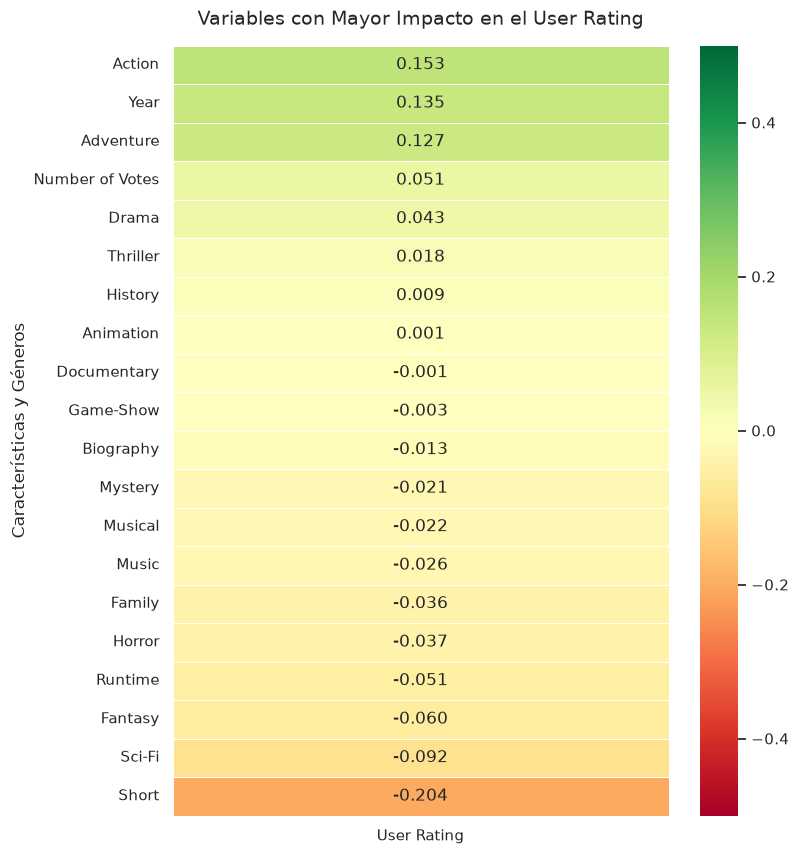

--- Listado completo de correlaciones con 'User Rating' ---


,User Rating
Action,0.153265
Year,0.135362
Adventure,0.127439
Number of Votes,0.051416
Drama,0.043322
Thriller,0.017790
History,0.008764
Animation,0.000890
Documentary,-0.001251
Game-Show,-0.002640


In [7]:
# ==========================================
# 4. Análisis de Correlaciones (Fase 2)
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calcular la matriz de correlación de Pearson para todo el dataset
corr_matrix = df_final.corr()

# 2. Extraer y ordenar las correlaciones de todas las variables contra 'User Rating'
# Excluimos 'User Rating' de la fila 0 (que siempre será 1.0)
corr_with_target = corr_matrix[['User Rating']].drop('User Rating').sort_values(by='User Rating', ascending=False)

# 3. Filtrar los extremos para el gráfico (Top 10 positivas y Top 10 negativas)
top_positive = corr_with_target.head(10)
top_negative = corr_with_target.tail(10)
top_correlations = pd.concat([top_positive, top_negative])

# 4. Generar el Mapa de Calor (Heatmap) enfocado
plt.figure(figsize=(8, 10))
sns.heatmap(top_correlations, annot=True, cmap='RdYlGn', vmin=-0.5, vmax=0.5, fmt=".3f", linewidths=0.5)
plt.title('Variables con Mayor Impacto en el User Rating', fontsize=14, pad=15)
plt.ylabel('Características y Géneros')
plt.show()

# 5. Mostrar la tabla completa por consola para el análisis
print("--- Listado completo de correlaciones con 'User Rating' ---")
display(corr_with_target)

In [12]:
# ==========================================
# 5. Función Unificada de Preprocesamiento (Fase 3)
# ==========================================
def preprocesar_anime(ruta_archivo):
    """
    Lee y limpia el dataset de anime, retornando un DataFrame listo para machine learning.
    """
    # 1. Carga y limpieza inicial
    df = pd.read_excel(ruta_archivo)
    df = df.drop_duplicates().copy()
    
    # 2. Tratar la variable objetivo
    df['User Rating'] = pd.to_numeric(df['User Rating'], errors='coerce')
    df = df.dropna(subset=['User Rating'])
    
    # 3. Eliminar ruido y columnas innecesarias
    cols_to_drop = ['Title', 'Summary', 'Stars', 'Certificate', 'Metascore', 'Episode', 'Episode Title', 'Gross']
    df = df.drop(columns=cols_to_drop, errors='ignore')
    
    # 4. Formatear números
    df['Number of Votes'] = pd.to_numeric(df['Number of Votes'].astype(str).str.replace(',', ''), errors='coerce')
    df['Runtime'] = pd.to_numeric(df['Runtime'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
    df['Year'] = pd.to_numeric(df['Year'].astype(str).str.extract(r'(\d{4})')[0], errors='coerce')
    
    # 5. Imputar nulos
    for col in ['Runtime', 'Year', 'Number of Votes']:
        df[col] = df[col].fillna(df[col].median())
        
    # 6. Dummies de Género y unión final
    genres_dummies = df['Genre'].str.split(', ').str.join('|').str.get_dummies(sep='|')
    df_final = pd.concat([df.drop('Genre', axis=1), genres_dummies], axis=1)
    
    return df_final



In [13]:
# ==========================================
# 6. Selección de Variables y Comparación (Fase 3)
# ==========================================
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression

# Aplicamos la función unificada
df_modelo = preprocesar_anime('/mnt/d/crist/OneDrive/Estudios/Latam_2024/5_Machine Learning/7_Aplicando lo aprendido/imdb_anime.xlsx')

# Separamos características (X) y objetivo (y)
X = df_modelo.drop('User Rating', axis=1)
y = df_modelo['User Rating']

# --- Método A: Filtros basados en Correlaciones ---
# Tomamos las 10 variables con mayor correlación absoluta (sin importar si es positiva o negativa)
correlaciones_abs = X.apply(lambda col: col.corr(y)).abs()
top_10_corr = correlaciones_abs.sort_values(ascending=False).head(10).index.tolist()

print("🥇 Top 10 variables por Filtro de Correlación:")
print(top_10_corr)

# --- Método B: Forward Selection ---
print("\n⏳ Ejecutando Forward Selection (esto tomará unos minutos)...")
modelo_lr = LinearRegression()

# Configuramos SFS para que elija las 10 mejores características sumándolas una a una
sfs = SequentialFeatureSelector(modelo_lr, n_features_to_select=10, direction='forward', n_jobs=-1)
sfs.fit(X, y)

top_10_forward = list(X.columns[sfs.get_support()])
print("🚀 Top 10 variables por Forward Selection:")
print(top_10_forward)

# --- Comparación ---
coincidencias = set(top_10_corr).intersection(set(top_10_forward))
print(f"\n🔄 Variables que coinciden en ambos métodos: {len(coincidencias)}")
print(list(coincidencias))

🥇 Top 10 variables por Filtro de Correlación:
['Short', 'Action', 'Year', 'Adventure', 'Sci-Fi', 'Fantasy', 'Number of Votes', 'Runtime', 'Drama', 'Horror']

⏳ Ejecutando Forward Selection (esto tomará unos minutos)...
🚀 Top 10 variables por Forward Selection:
['Runtime', 'Action', 'Adventure', 'Comedy', 'Drama', 'History', 'Sci-Fi', 'Short', 'Sport', 'Thriller']

🔄 Variables que coinciden en ambos métodos: 6
['Sci-Fi', 'Action', 'Adventure', 'Runtime', 'Drama', 'Short']


# Conclusión Final: Selección de Variables y Comparación de Métodos
Tras aplicar y comparar dos métodos distintos de selección de características (Filtro por Correlación y Forward Selection), hemos identificado un subconjunto robusto de variables predictoras para el User Rating.

1. Comparación de los Métodos:

    - Filtro por Correlación (Univariado): Este método evaluó cada variable de forma aislada contra la variable objetivo. Destacó variables como Number of Votes y Year, indicando que, por sí solas, tienen una relación lineal fuerte con la calificación del anime.

    - Forward Selection (Multivariado): Al utilizar un modelo de Regresión Lineal para añadir variables iterativamente, este método evaluó cómo las características interactúan entre sí. Es notable que Number of Votes no haya quedado en el Top 10 de este método, lo que sugiere que la información que aporta ya está siendo explicada por la combinación de otras variables (como los géneros y el tiempo de duración) cuando se analizan en conjunto.

2. Coincidencias con el Análisis Exploratorio:
Las variables que sobrevivieron a ambos métodos (la intersección) fueron 6: ['Sci-Fi', 'Action', 'Adventure', 'Runtime', 'Drama', 'Short'].

Sí existe una coincidencia directa con el análisis exploratorio previo (Mapa de Calor). Durante la exploración visual, ya habíamos detectado que géneros con bases de fans muy dedicadas como Drama, Action, Sci-Fi y Adventure presentaban las mayores correlaciones (tanto positivas como negativas) con el User Rating. Adicionalmente, el formato (Runtime y si es un anime tipo Short) demostró ser un factor estructural determinante que el modelo considera indispensable para predecir si un anime será bien o mal calificado.

Recomendación: Para el entrenamiento del modelo de recomendación final de la plataforma de streaming, se sugiere priorizar estas 6 variables coincidentes, ya que han demostrado ser estadísticamente significativas y predictivas bajo dos enfoques analíticos completamente diferentes.